In [1]:
#Section 1 - Linear Regression, Outliers, and Regularization

In [2]:
#Importing Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [3]:
rng = np.random.default_rng(230477)
X = rng.uniform(-3,3, size=(160,1))
y = 2.5 + 1.8*X[:,0] + rng.normal(0,0.8,size=160)

#add large errors to 12 observations
outlier_idx = rng.choice(len(y), size=12, replace=False)
y[outlier_idx] += rng.uniform(10, 15, size=12)

In [4]:
#Section 1 - Question 1 :- To be answered in the report
#Section 2 - Question 2 :- Below is the code for the second question

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Fitting the Linear Regression model to the training data
model = LinearRegression()
model.fit(X_train, y_train)
#Displaying the coefficients and intercept of the fitted model
print("----------------------------------------------------")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
#Calculating the Mean Squared Error (MSE) for both training and testing sets
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print("----------------------------------------------------")
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

----------------------------------------------------
Coefficients: [1.75469598]
Intercept: 3.4119824455619474
----------------------------------------------------
Train MSE: 10.869229538776203
Test MSE: 13.112669850851674


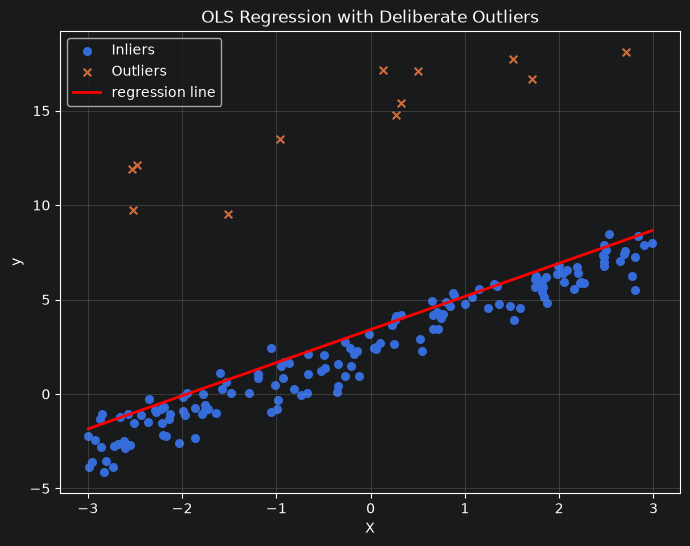

In [5]:
X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(8, 6))

# Creating a mask for the inliers
inlier_mask = np.ones(len(y), dtype=bool)
inlier_mask[outlier_idx] = False

# Plot inliers
plt.scatter(X[inlier_mask], y[inlier_mask], label="Inliers",s=30, alpha=1)

# Plot outliers
plt.scatter(X[outlier_idx], y[outlier_idx], marker="x", s=30, label="Outliers")

# Regression line
plt.plot(X_line, y_line, linewidth=2, label="regression line", color="red")

plt.xlabel("X")
plt.ylabel("y")
plt.title("OLS Regression with Deliberate Outliers")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [6]:
#Section 1 - Question 3 :- Below is the code for the third question, Closed Form Matrix expression derivation in report

# Preserve original sample indices during train-test splitting
indices = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X,y,indices,test_size=0.2, random_state=42)
# ---------------- WLS weights ----------------
weights_train = np.ones(len(y_train))
# Identify known outliers that are present in training data
is_outlier_train = np.isin(idx_train, outlier_idx)
# Down-weight outliers
weights_train[is_outlier_train] = 0.05
# Weighting matrix A
A = np.diag(weights_train)
# Augmented design matrix [1, x]
X_train_aug = np.column_stack((np.ones(len(X_train)), X_train[:, 0]))
# WLS closed-form solution
w_wls = np.linalg.solve(X_train_aug.T @ A @ X_train_aug, X_train_aug.T @ A @ y_train)

intercept_wls = w_wls[0]
slope_wls = w_wls[1]
print("----------------------------------------------------")
print(f"OLS intercept: {model.intercept_:.4f}")
print(f"OLS slope: {model.coef_[0]:.4f}")
print("----------------------------------------------------")
print(f"WLS intercept: {intercept_wls:.4f}")
print(f"WLS slope: {slope_wls:.4f}")


----------------------------------------------------
OLS intercept: 3.4120
OLS slope: 1.7547
----------------------------------------------------
WLS intercept: 2.5870
WLS slope: 1.8024


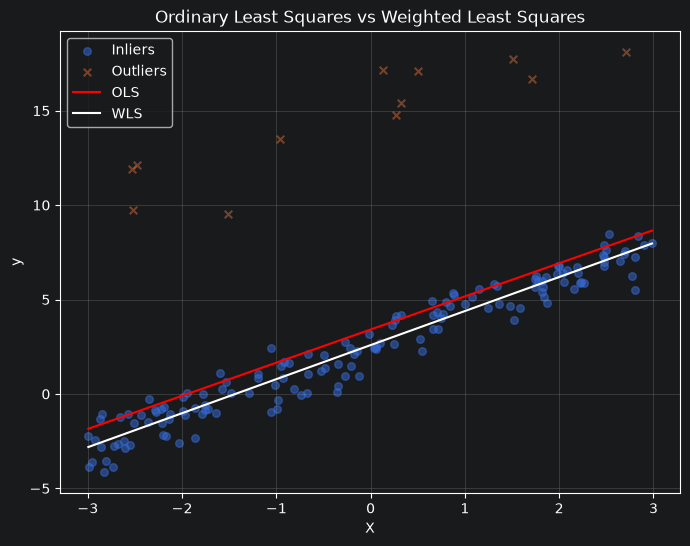

In [7]:
# ---------------- Plot ----------------
X_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

y_ols_line = model.predict(X_line)
y_wls_line = intercept_wls + slope_wls * X_line[:, 0]

inlier_mask = np.ones(len(y), dtype=bool)
inlier_mask[outlier_idx] = False

plt.figure(figsize=(8, 6))

plt.scatter(X[inlier_mask], y[inlier_mask], label="Inliers", s=30, alpha=0.5)

plt.scatter(X[outlier_idx], y[outlier_idx], marker="x", s=30, label="Outliers", alpha=0.5)

plt.plot(X_line, y_ols_line, label="OLS", color="red")
plt.plot(X_line, y_wls_line, label="WLS", color="white")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Ordinary Least Squares vs Weighted Least Squares")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [8]:
#Section 1 - Question 4
#Creating Expanded Dataset with nine pure noise variables
X_noise=rng.normal(size=(X.shape[0], 9))
X10 = np.column_stack([X, X_noise])

In [9]:
#Splitting data into training and testing sets
X_train_, X_test_, y_train_, y_test_ = train_test_split(X10, y, test_size=0.2, random_state=42)

In [10]:
#Defining OLS model pipeline with standardization
ols_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])
ols_cv_scores = cross_val_score(ols_model, X_train_, y_train_, cv=5, scoring="neg_mean_squared_error")
ols_cv_mse = -ols_cv_scores.mean()
ols_model.fit(X_train_, y_train_)
ols_test_pred = ols_model.predict(X_test_)
ols_test_mse = mean_squared_error(y_test_, ols_test_pred)

print(f"OLS 5-fold CV MSE: {ols_cv_mse:.4f}")
print(f"OLS Test-set MSE:   {ols_test_mse:.4f}")

OLS 5-fold CV MSE: 13.9317
OLS Test-set MSE:   13.1483


In [11]:
# Ridge Regression with Cross-Validation for Hyperparameter Tuning
alpha_values = [1e-3, 1e-2, 1e-1, 1, 10]

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
ridge_grid = GridSearchCV(ridge_model, {"model__alpha": alpha_values}, cv=5, scoring="neg_mean_squared_error")
ridge_grid.fit(X_train_, y_train_)

# Print CV MSE for every alpha
cv_results = ridge_grid.cv_results_
print("Ridge Cross-Validation Results:")
for alpha, neg_mse in zip(
    cv_results["param_model__alpha"],
    cv_results["mean_test_score"]
):
    print(f"alpha = {alpha:<6}  CV MSE = {-neg_mse:.4f}")

# Best alpha
best_ridge_alpha = ridge_grid.best_params_["model__alpha"]
best_ridge_cv_mse = -ridge_grid.best_score_

print(f"\nBest alpha: {best_ridge_alpha}")
print(f"Best CV MSE: {best_ridge_cv_mse:.4f}")

# Test-set performance
best_ridge = ridge_grid.best_estimator_
ridge_test_pred = best_ridge.predict(X_test_)
ridge_test_mse = mean_squared_error(
    y_test_,
    ridge_test_pred
)
print(f"Test MSE: {ridge_test_mse:.4f}")

Ridge Cross-Validation Results:
alpha = 0.001   CV MSE = 13.9316
alpha = 0.01    CV MSE = 13.9313
alpha = 0.1     CV MSE = 13.9279
alpha = 1.0     CV MSE = 13.8958
alpha = 10.0    CV MSE = 13.6940

Best alpha: 10
Best CV MSE: 13.6940
Test MSE: 13.1248


In [12]:
# Ridge Regression with Cross-Validation for Hyperparameter Tuning
alpha_values = [1e-3, 1e-2, 1e-1, 1, 10]

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])
lasso_grid = GridSearchCV(lasso_model, {"model__alpha": alpha_values}, cv=5, scoring="neg_mean_squared_error")
lasso_grid.fit(X_train_, y_train_)

# Print CV MSE for every alpha
cv_results = lasso_grid.cv_results_
print("Lasso Cross-Validation Results:")
for alpha, neg_mse in zip(
    cv_results["param_model__alpha"],
    cv_results["mean_test_score"]
):
    print(f"alpha = {alpha:<6}  CV MSE = {-neg_mse:.4f}")

# Best alpha
best_lasso_alpha = lasso_grid.best_params_["model__alpha"]
best_lasso_cv_mse = -lasso_grid.best_score_

print(f"\nBest alpha: {best_lasso_alpha}")
print(f"Best CV MSE: {best_lasso_cv_mse:.4f}")

# Test-set performance
best_lasso = lasso_grid.best_estimator_
lasso_test_pred = best_lasso.predict(X_test_)
lasso_test_mse = mean_squared_error(
    y_test_,
    lasso_test_pred
)
print(f"Test MSE: {lasso_test_mse:.4f}")

Lasso Cross-Validation Results:
alpha = 0.001   CV MSE = 13.9205
alpha = 0.01    CV MSE = 13.8192
alpha = 0.1     CV MSE = 12.9658
alpha = 1.0     CV MSE = 12.2590
alpha = 10.0    CV MSE = 21.1185

Best alpha: 1
Best CV MSE: 12.2590
Test MSE: 14.0367


In [13]:
print("OLS Parameters")
print("Coefficients:", ols_model.named_steps["model"].coef_)

print("\nBest Ridge Parameters")
print("Best alpha:", best_ridge_alpha)
print("Coefficients:", best_ridge.named_steps["model"].coef_)

print("\nBest Lasso Parameters")
print("Best alpha:", best_lasso_alpha)
print("Coefficients:", best_lasso.named_steps["model"].coef_)

OLS Parameters
Coefficients: [ 3.20269994  0.0214084   0.1961103  -0.07081488  0.30564347  0.20158973
  0.02888247 -0.0209606  -0.06474853  0.14489134]

Best Ridge Parameters
Best alpha: 10
Coefficients: [ 2.95915133 -0.00783863  0.17852794 -0.08015253  0.28674409  0.16369326
  0.01386214 -0.04501032 -0.08185977  0.13302526]

Best Lasso Parameters
Best alpha: 1
Coefficients: [ 2.19809965 -0.          0.         -0.          0.          0.
 -0.         -0.         -0.          0.        ]


In [14]:
#Section 1 - Question 5, Question 6 in report

In [15]:
#Section 2
import pandas as pd
from sklearn.datasets import make_classification

In [16]:
#Listing 2 for data generation
X_num, y = make_classification(
    n_samples=600,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    class_sep=0.9,
    weights=[0.68, 0.32],
    flip_y=0.03,
    random_state=21
)

df = pd.DataFrame(X_num, columns=["x1", "x2", "x3", "x4"])
rng = np.random.default_rng(21)
df["region"] = rng.choice(["north", "south", "east"], size=len(df))
df["device"] = rng.choice(["mobile", "desktop"], size=len(df))
df.loc[rng.choice(len(df),25,replace=False), "x3"] = np.nan

In [17]:
 #Section 2 - Question 1 in the report
 #Section 2 - Question 2 code is in following cells
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

In [18]:
numerical_features = ["x1", "x2", "x3", "x4"]
categorical_features = ["region", "device"]

#Splitting the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(
    df,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

#Numerical preprocessing pipeline: Impute missing values with median and scale features
numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#Categorical preprocessing pipeline: Impute missing values with most frequent and apply one-hot encoding
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

#Combine numerical and categorical transformers into a single preprocessor using ColumnTransformer
preprocessor = ColumnTransformer([
    (
        "num",
        numerical_transformer,
        numerical_features
    ),
    (
        "cat",
        categorical_transformer,
        categorical_features
    )
])

#Final model pipeline: Preprocess the data and then apply Logistic Regression
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

#Fitting data to defined model
model.fit(X_train, y_train)

print("----------------------------------------------------")
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

----------------------------------------------------
Training Accuracy: 0.8854166666666666
Testing Accuracy: 0.85


In [19]:
#Section 2 - Question 3
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [20]:
# Logistic Regression pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear"
    ))
])

# Hyperparameter grid
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__l1_ratio": [0, 1]
}

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv
)

grid_search.fit(X_train, y_train)

# Display CV F1 for every parameter combination
results = grid_search.cv_results_
print("Cross-Validation Results:")
for C, penalty, score in zip(
    results["param_classifier__C"],
    results["param_classifier__l1_ratio"],
    results["mean_test_score"]
):
    print(
        f"C = {float(C):<6g} "
        f"Penalty = {penalty:<2} "
        f"CV F1 = {score:.4f}"
    )
# Best result
best_params = grid_search.best_params_
best_cv_f1 = grid_search.best_score_

print("\nBest Parameters:")
print(best_params)

print(f"Best CV F1-score: {best_cv_f1:.4f}")


# Store best fitted model for Q4
best_model = grid_search.best_estimator_

Cross-Validation Results:
C = 0.01   Penalty = 0  CV F1 = 0.7843
C = 0.01   Penalty = 1  CV F1 = 0.7418
C = 0.1    Penalty = 0  CV F1 = 0.8033
C = 0.1    Penalty = 1  CV F1 = 0.8007
C = 1      Penalty = 0  CV F1 = 0.8073
C = 1      Penalty = 1  CV F1 = 0.8148
C = 10     Penalty = 0  CV F1 = 0.7997
C = 10     Penalty = 1  CV F1 = 0.7997
C = 100    Penalty = 0  CV F1 = 0.7997
C = 100    Penalty = 1  CV F1 = 0.7997

Best Parameters:
{'classifier__C': 1, 'classifier__l1_ratio': 1}
Best CV F1-score: 0.8148


In [21]:
#Section 2 - Question 4
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay)


In [22]:
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.8583
Precision: 0.7895
Recall:    0.7692
F1-score:  0.7792


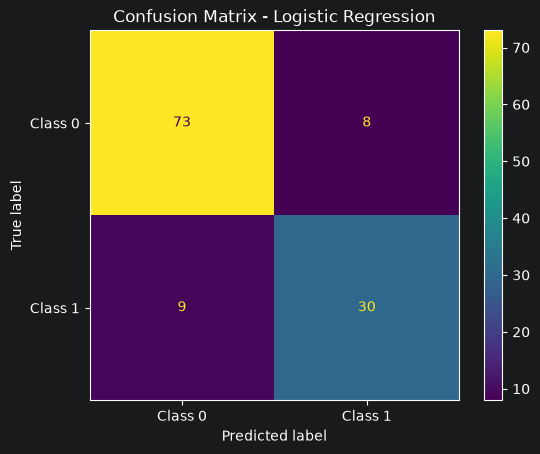

In [23]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [24]:
#Section 2 - Question 5
y_prob = best_model.predict_proba(X_test)[:, 1]

y_pred_035 = (y_prob >= 0.35).astype(int)
y_pred_050 = (y_prob >= 0.50).astype(int)

precision_035 = precision_score(y_test, y_pred_035)
recall_035 = recall_score(y_test, y_pred_035)

precision_050 = precision_score(y_test, y_pred_050)
recall_050 = recall_score(y_test, y_pred_050)

print("Precision and Recall for Threshold 0.50:=================")
print(f"Precision: {precision_050:.4f}")
print(f"Recall: {recall_050:.4f}")
print("Precision and Recall for Threshold 0.35:=================")
print(f"Precision: {precision_035:.4f}")
print(f"Recall: {recall_035:.4f}")

Precision and Recall for Threshold 0.50:=================
Precision: 0.7895
Recall: 0.7692
Precision and Recall for Threshold 0.35:=================
Precision: 0.6875
Recall: 0.8462


In [25]:
#Section 2 - Question 6 in the report

In [26]:
#Section 3
#Code to generate Binary classification data
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X,y = make_blobs(
    n_samples=1200,
    centers=[[-2.2,-0.5],[2.0,1.2]],
    cluster_std=[1.45, 1.65],
    random_state=8
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [27]:
#Section 3 - Question 1 in the report

In [28]:
#Section 3 - Question 2 code
def sigmoid(z):
    z = np.asarray(z)
    return np.where(
        z >= 0,
        1 / (1 + np.exp(-z)),
        np.exp(z) / (1 + np.exp(z))
    )


def cross_entropy(y, p, eps=1e-15):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(
        y * np.log(p)
        + (1 - y) * np.log(1 - p)
    )

In [29]:
#Section 3 - Question 3 code
#Implementing Logistic Regression using Batch Gradient Descent
#Adding bias term to the training and testing data
X_train_ = np.column_stack([np.ones(len(X_train)),X_train])
X_test_ = np.column_stack([np.ones(len(X_test)),X_test])

#Function to calculate gradients for logistic regression
def compute_gradients(X, y, w):
    m=len(y)
    z = X @ w
    p = sigmoid(z)
    gradients = (1/m) * (X.T @ (p - y))
    return gradients

def batch_gradient_descent(X,y,learning_rate=0.1,max_iterations=300,tolerance=1e-8):
    w = np.zeros(X.shape[1])
    loss_history = []
    for iteration in range(max_iterations):
        z = X @ w
        p = sigmoid(z)

        loss = cross_entropy(y, p)
        if((iteration + 1) % 10 == 0 or iteration == max_iterations - 1):
            print(f"Iteration {iteration+1}/{max_iterations}, Loss: {loss:.6f}")
        loss_history.append(loss)

        gradients = compute_gradients(X, y, w)

        w = w - learning_rate * gradients

        if iteration > 0:
            loss_change = abs(loss_history[-1] - loss_history[-2])
            #Early stopping if the change in loss is less than the specified tolerance
            if loss_change < tolerance:
                print(f"Early stopping at iteration {iteration+1} due to minimal change in loss.")
                break

    iterations_used = iteration + 1

    return w, loss_history, iterations_used


In [30]:
#Running Batch Gradient Descent with specified learning rate and maximum iterations
w, loss_history, iterations_used = batch_gradient_descent(X_train_, y_train)

Iteration 10/300, Loss: 0.297832
Iteration 20/300, Loss: 0.233251
Iteration 30/300, Loss: 0.207903
Iteration 40/300, Loss: 0.194227
Iteration 50/300, Loss: 0.185675
Iteration 60/300, Loss: 0.179848
Iteration 70/300, Loss: 0.175646
Iteration 80/300, Loss: 0.172493
Iteration 90/300, Loss: 0.170055
Iteration 100/300, Loss: 0.168126
Iteration 110/300, Loss: 0.166571
Iteration 120/300, Loss: 0.165298
Iteration 130/300, Loss: 0.164244
Iteration 140/300, Loss: 0.163362
Iteration 150/300, Loss: 0.162616
Iteration 160/300, Loss: 0.161982
Iteration 170/300, Loss: 0.161438
Iteration 180/300, Loss: 0.160968
Iteration 190/300, Loss: 0.160562
Iteration 200/300, Loss: 0.160208
Iteration 210/300, Loss: 0.159898
Iteration 220/300, Loss: 0.159626
Iteration 230/300, Loss: 0.159386
Iteration 240/300, Loss: 0.159175
Iteration 250/300, Loss: 0.158987
Iteration 260/300, Loss: 0.158820
Iteration 270/300, Loss: 0.158672
Iteration 280/300, Loss: 0.158539
Iteration 290/300, Loss: 0.158421
Iteration 300/300, Loss

In [31]:
# Print final model parameters
print("\nFinal weights:")
print(w)

print(f"Total iterations used: {iterations_used}")

# Test-set predictions
z_test = X_test_ @ w
p_test = sigmoid(z_test)

y_pred = (p_test >= 0.5).astype(int)

# Test-set accuracy
test_accuracy = np.mean(y_pred == y_test)

print(f"Test accuracy: {test_accuracy:.4f}")


Final weights:
[-0.02110817  1.77074229  0.70004636]
Total iterations used: 300
Test accuracy: 0.9333


In [32]:
# Section 3 - Question 4 code
# Mini-Batch Gradient Descent Implementation

def mini_batch_gradient_descent(X,y,batch_size=32,learning_rate=0.05,max_epochs=100,tolerance=1e-8,random_state=42):

    w = np.zeros(X.shape[1])
    loss_history = []

    n_samples = len(y)

    rng = np.random.default_rng(random_state)

    for epoch in range(max_epochs):

        # Shuffle training samples at the beginning of each epoch
        indices = rng.permutation(n_samples)

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # Process mini-batches
        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            gradients = compute_gradients(X_batch,y_batch,w)

            w = w - learning_rate * gradients

        # Calculate full training loss after each epoch
        z = X @ w
        p = sigmoid(z)

        loss = cross_entropy(y, p)
        loss_history.append(loss)
        if((epoch + 1) % 10 == 0 or epoch == max_epochs - 1):
            print(
                f"Epoch {epoch + 1}/{max_epochs}, "
                f"Loss: {loss:.6f}"
            )

        # Check convergence
        if epoch > 0:

            loss_change = abs(
                loss_history[-1] - loss_history[-2]
            )
            if loss_change < tolerance:
                print(
                    f"\nConvergence reached at epoch "
                    f"{epoch + 1}"
                )
                print(
                    f"Loss change: {loss_change:.2e}"
                )
                break
    epochs_used = epoch + 1
    return w, loss_history, epochs_used

In [33]:
w_mbgd, loss_history_mbgd, epochs_used = mini_batch_gradient_descent(
    X_train_,
    y_train
)

print("\nFinal Mini-Batch GD weights:")
print(w_mbgd)

print(f"Total epochs used: {epochs_used}")
# Test-set predictions
z_test_ = X_test_ @ w_mbgd
p_test_ = sigmoid(z_test_)

y_pred_ = (p_test_ >= 0.5).astype(int)

# Test-set accuracy
test_accuracy_ = np.mean(y_pred_ == y_test)

print(f"Test accuracy: {test_accuracy_:.4f}")

Epoch 10/100, Loss: 0.162584
Epoch 20/100, Loss: 0.158318
Epoch 30/100, Loss: 0.157543
Epoch 40/100, Loss: 0.157356
Epoch 50/100, Loss: 0.157303
Epoch 60/100, Loss: 0.157287
Epoch 70/100, Loss: 0.157283
Epoch 80/100, Loss: 0.157281

Convergence reached at epoch 89
Loss change: 6.09e-09

Final Mini-Batch GD weights:
[-0.02413254  1.96545516  0.78787423]
Total epochs used: 89
Test accuracy: 0.9333


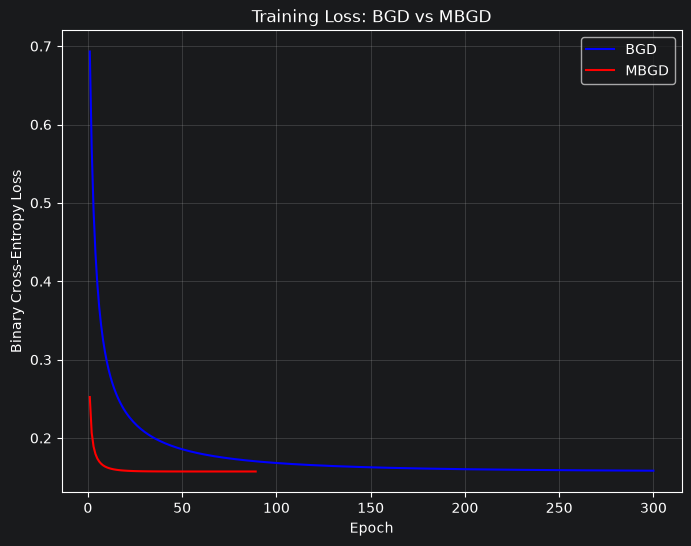

In [34]:
#Plotting the loss history for both Batch Gradient Descent and Mini-Batch Gradient Descent
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(loss_history) + 1),loss_history,label="BGD",color='blue')
plt.plot(range(1, len(loss_history_mbgd) + 1),loss_history_mbgd,label="MBGD",color='red')

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss: BGD vs MBGD")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [35]:
#Section 3 - Question 5 code
# Function to compute Hessian
def hessian(X, w):
    m = len(X)
    z = X @ w
    p = sigmoid(z)
    R = np.diag(p * (1 - p))
    H = (1 / m) * (X.T @ R @ X)
    return H


# Newton's Method
def newtons_method(X,y,max_iterations=20,tolerance=1e-8,damping=1e-6):
    # Initialize weights
    w = np.zeros(X.shape[1])
    loss_history = []
    for iteration in range(max_iterations):
        # Predictions
        z = X @ w
        p = sigmoid(z)
        # Current loss
        loss = cross_entropy(y, p)
        loss_history.append(loss)
        if ((iteration + 1) % 5 == 0 or iteration == max_iterations - 1):
            print(
                f"Iteration {iteration + 1}/{max_iterations}, "
                f"Loss: {loss:.6f}"
            )
        # Gradient
        gradients = compute_gradients(X, y, w)
        # Hessian
        H = hessian(X, w)
        # Damped Hessian
        H_damped = H + damping * np.eye(len(w))
        # Newton search direction
        direction = np.linalg.solve(
            H_damped,
            gradients
        )
        # Update weights
        w = w - direction
        # Early stopping
        if iteration > 0:
            loss_change = abs(
                loss_history[-1]
                - loss_history[-2]
            )
            if loss_change < tolerance:
                print(
                    f"Early stopping at iteration "
                    f"{iteration + 1}"
                )
                break

    iterations_used = iteration + 1
    return w, loss_history, iterations_used

In [36]:
# Run Newton's Method
w_newton, loss_history_newton, newton_iterations = newtons_method(X_train_,y_train)
# Display results
print("\nFinal weights:")
print(w_newton)

print(
    f"Total iterations used: "
    f"{newton_iterations}"
)
# Test-set predictions
z_test__ = X_test_ @ w_newton
p_test__ = sigmoid(z_test__)

y_pred__ = (p_test__ >= 0.5).astype(int)

# Test-set accuracy
test_accuracy__ = np.mean(y_pred__ == y_test)

print(f"Test accuracy: {test_accuracy__:.4f}")

Iteration 5/20, Loss: 0.158710
Early stopping at iteration 9

Final weights:
[-0.02409262  1.96812288  0.79065095]
Total iterations used: 9
Test accuracy: 0.9333


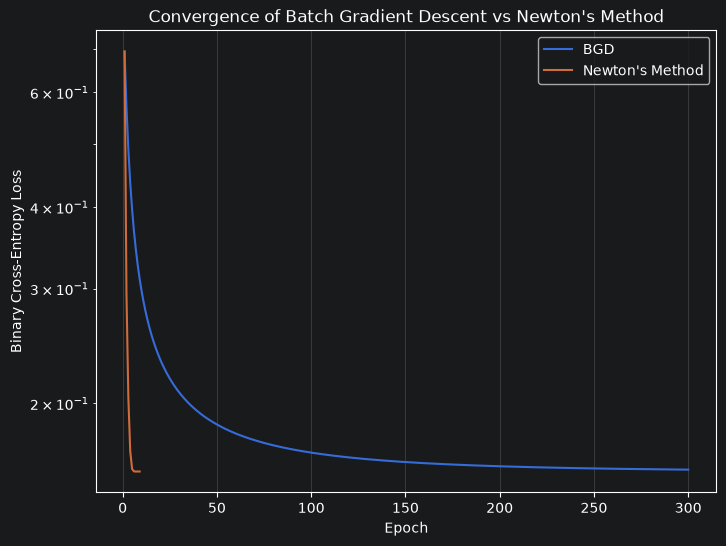

In [37]:
#Section 3 - Question 6 code
plt.figure(figsize=(8, 6))

plt.plot(range(1, len(loss_history) + 1),loss_history,label="BGD")
plt.plot(range(1, len(loss_history_newton) + 1),loss_history_newton,label="Newton's Method")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Convergence of Batch Gradient Descent vs Newton's Method")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Iteration 10/300, Loss: 10.123561
Iteration 20/300, Loss: 16.272321
Iteration 30/300, Loss: 22.949379
Iteration 40/300, Loss: 23.424929
Iteration 50/300, Loss: 10.086709
Iteration 60/300, Loss: 10.029429
Iteration 70/300, Loss: 9.589511
Iteration 80/300, Loss: 9.279202
Iteration 90/300, Loss: 9.833230
Iteration 100/300, Loss: 9.724152
Iteration 110/300, Loss: 9.949394
Iteration 120/300, Loss: 9.944194
Iteration 130/300, Loss: 9.886161
Iteration 140/300, Loss: 9.877337
Iteration 150/300, Loss: 9.873696
Iteration 160/300, Loss: 9.850400
Iteration 170/300, Loss: 9.833768
Iteration 180/300, Loss: 9.802139
Iteration 190/300, Loss: 9.785694
Iteration 200/300, Loss: 9.766354
Iteration 210/300, Loss: 9.744284
Iteration 220/300, Loss: 9.719850
Iteration 230/300, Loss: 9.696498
Iteration 240/300, Loss: 9.676818
Iteration 250/300, Loss: 9.662653
Iteration 260/300, Loss: 9.649140
Iteration 270/300, Loss: 9.637185
Iteration 280/300, Loss: 9.627133
Iteration 290/300, Loss: 9.617445
Iteration 300/300

C:\Users\user\AppData\Local\Temp\ipykernel_25952\833492940.py:6: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(-z)),
C:\Users\user\AppData\Local\Temp\ipykernel_25952\833492940.py:7: RuntimeWarning: overflow encountered in exp
  np.exp(z) / (1 + np.exp(z))
C:\Users\user\AppData\Local\Temp\ipykernel_25952\833492940.py:7: RuntimeWarning: invalid value encountered in divide
  np.exp(z) / (1 + np.exp(z))


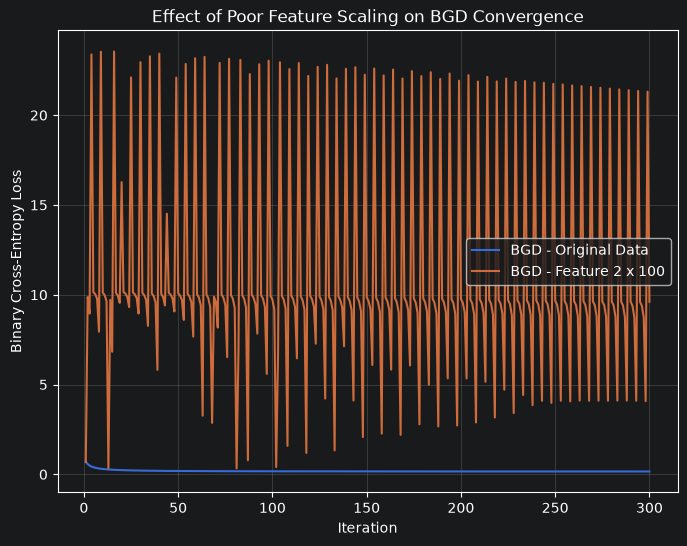


Condition number - Original data: 9.03
Condition number - Unscaled data: 35958.96


In [40]:
# Section 3 - Question 7 code
# Copy the original train/test data
X_train_unscaled = X_train.copy()
X_test_unscaled = X_test.copy()

# Multiply the second feature by 100
X_train_unscaled[:, 1] = 100 * X_train_unscaled[:, 1]
X_test_unscaled[:, 1] = 100 * X_test_unscaled[:, 1]

# Add bias column
X_train_unscaled_ = np.column_stack([np.ones(len(X_train_unscaled)),X_train_unscaled])

X_test_unscaled_ = np.column_stack([np.ones(len(X_test_unscaled)),X_test_unscaled])

# Run Batch Gradient Descent using the same settings as Question 3
w_unscaled, loss_history_unscaled, iterations_unscaled = batch_gradient_descent(X_train_unscaled_,y_train,learning_rate=0.1,max_iterations=300,tolerance=1e-8)

# Display results
print("\nFinal weights for unscaled data:")
print(w_unscaled)

print(f"Total iterations used: {iterations_unscaled}")

# Compare original and unscaled loss histories
plt.figure(figsize=(8, 6))

plt.plot(range(1, len(loss_history) + 1),loss_history,label="BGD - Original Data")

plt.plot(range(1, len(loss_history_unscaled) + 1),loss_history_unscaled,label="BGD - Feature 2 x 100")

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Effect of Poor Feature Scaling on BGD Convergence")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Compute Hessian condition numbers at initial weights w = 0
w0_original = np.zeros(X_train_.shape[1])
w0_unscaled = np.zeros(X_train_unscaled_.shape[1])

H_original = hessian(X_train_, w0_original)
H_unscaled = hessian(X_train_unscaled_, w0_unscaled)

condition_original = np.linalg.cond(H_original)
condition_unscaled = np.linalg.cond(H_unscaled)

print(f"\nCondition number - Original data: {condition_original:.2f}")
print(f"Condition number - Unscaled data: {condition_unscaled:.2f}")

In [41]:
#Section 3 - Question 7 Explanation in the report